In [ ]:
#Load libraries
import os
import re
import sys
import collections
import argparse
import itertools
import matplotlib
import glob
import math
import scipy.io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
import scipy.sparse as sp_sparse
import scanpy as sc 
import scanpy.external as sce
from cnmf import cNMF
from scipy.stats import hypergeom
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict
from scipy import sparse, io
import scipy.cluster.hierarchy as sch
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import pickle
import seaborn as sns
import gseapy as gp
from gseapy import Msigdb
import requests
from matplotlib.colors import LinearSegmentedColormap

In [ ]:
#This script is run after running the cNMF pipeline and selecting optimal K=200

In [ ]:
#Load the file with information about which perturbation dysregulates which gene program 
K_200 = pd.read_csv("compare_score_k200.csv")
K_200["Corrected p-value (BH)"] = K_200["Corrected p-value (BH)"].round(4)
K_200['Program'] = K_200['Score Column'].str.split('_').str[1]
K_200['Program'] = pd.to_numeric(K_200['Program'], errors='coerce')
K_200['BaseGene'] = K_200['Gene'].apply(lambda x: x.split('_P')[0] if '_P' in x else x)
#Filter to retain only significant hits
K_200 =  K_200[K_200["Corrected p-value (BH)"]<0.001]

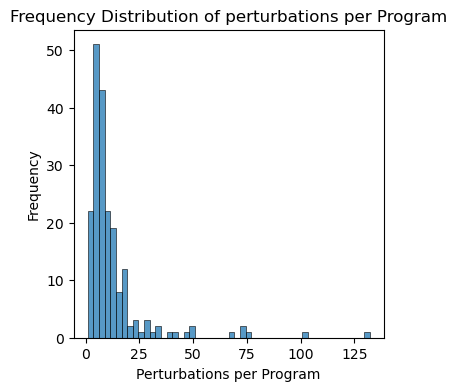

In [ ]:
#QC plot 1
gene_count_per_program = K_200.groupby('Program')['Gene'].nunique().reset_index()
gene_count_per_program.columns = ['Program', 'Unique Gene Count']
plt.figure(figsize=(4, 4))
sns.histplot(gene_count_per_program['Unique Gene Count'], kde=False,  bins=50)
plt.xlabel('Perturbations per Program')
plt.ylabel('Frequency')
plt.title('Frequency Distribution of perturbations per Program')
plt.savefig("Freq_perturbations_per_program_QC.pdf")
plt.show()

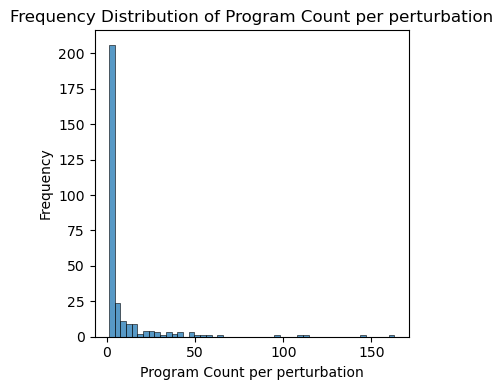

In [ ]:
#QC plot 2
program_count_per_gene = K_200.groupby('Gene')['Program'].nunique().reset_index()
program_count_per_gene.columns = ['Gene', 'Program Count']
plt.figure(figsize=(4, 4))
sns.histplot(program_count_per_gene['Program Count'], kde=False, bins=50)
plt.xlabel('Program Count per perturbation')
plt.ylabel('Frequency')
plt.title('Frequency Distribution of Program Count per perturbation')
plt.savefig("Freq_program_count_per_pert_QC.pdf")
plt.tight_layout()
plt.show()

In [ ]:
#Load the file with information gene ontology terms per gene program 
with open('Prod1_neuron_GO_all_enriched_results.pkl', 'rb') as file:
    enrichment_results = pickle.load(file)
GO_200 = enrichment_results[200]
GO_200['neg_log10_p_value'] = -np.log10(GO_200['Adjusted P-value'])
#Filter to retain significant terms
GO_200 = GO_200[GO_200["Adjusted P-value"]<0.05]
GO_200 = GO_200.sort_values(by = "neg_log10_p_value",ascending=False)

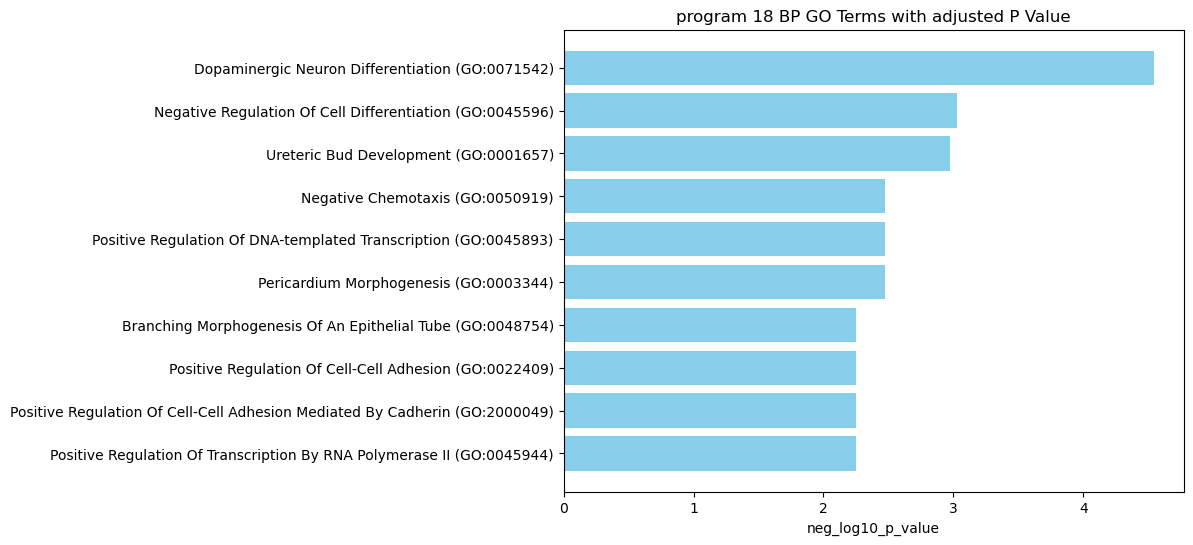

In [ ]:
#Example GO terms plot for program 18
GO_col1 = GO_200[GO_200["Source"]==18]
GO_col1 = GO_col1[GO_col1["Gene_set"]=="GO_Biological_Process_2023"]
GO_col1 = GO_col1[GO_col1["Adjusted P-value"]<0.05]
GO_col1 = GO_col1.sort_values(by = "neg_log10_p_value",ascending=False)
GO_col1 = GO_col1.iloc[:10,:]
plt.figure(figsize=(8, 6))
plt.barh(GO_col1['Term'], GO_col1['neg_log10_p_value'], color='skyblue')
plt.xlabel('neg_log10_p_value')
plt.title('program 18 BP GO Terms with adjusted P Value')
plt.gca().invert_yaxis()
plt.savefig("GP18_GOterms.pdf",bbox_inches='tight')
plt.show()

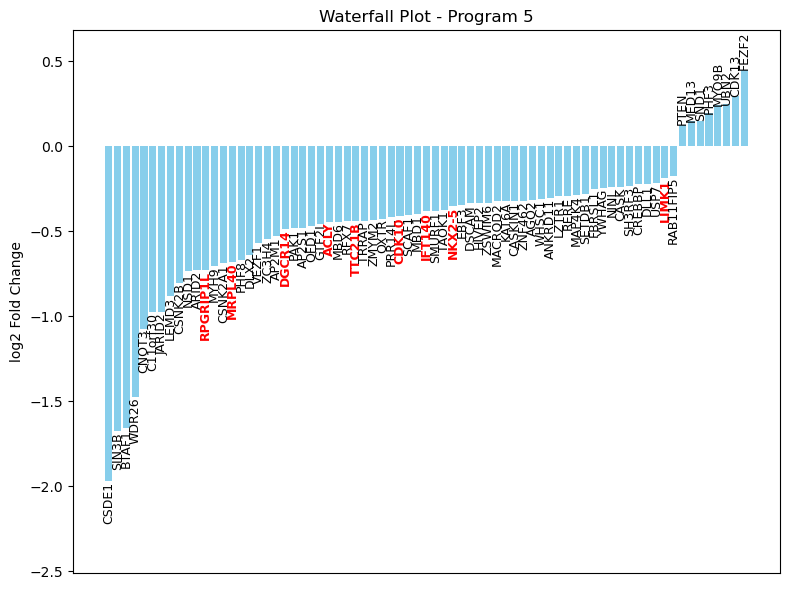

In [ ]:
#Example waterfall plot for program 5
asd_list = pd.read_csv("SFARI-Gene_genes_10-23-2025release_11-17-2025export.csv")
asd_list = asd_list["gene-symbol"].to_list()
prog_pert = K_200[K_200["Program"] == 5]
df = prog_pert.sort_values(by='Log2 Fold Change', ascending=True).reset_index(drop=True)
df['BaseGene'] = df['BaseGene'].str.split('_').str[0]
plt.figure(figsize=(8, 6))
bars = plt.bar(range(len(df)), df['Log2 Fold Change'], color='skyblue')
plt.xticks([], [])
for i, row in df.iterrows():
    gene_name = row['BaseGene']
    y_val = row['Log2 Fold Change']
    if gene_name in asd_list:
        text_color = 'black'
        font_weight = 'normal'
    else:
        text_color = 'red'
        font_weight = 'bold'

    va = "bottom" if y_val > 0 else "top"
    
    plt.text(i,
             y_val,
             gene_name,
             ha='center',
             va=va,
             rotation=90,
             fontsize=9,
             fontweight=font_weight,
             color=text_color)

plt.ylabel('log2 Fold Change')
plt.title('Waterfall Plot - Program 5')
ymin, ymax = plt.ylim()
plt.ylim(ymin * 1.2, ymax * 1.2)
plt.tight_layout()
plt.savefig('program_5_waterfall_plot.pdf', dpi=300)
plt.show()